# **1 Этап**



# **Описание набора данных**

Данные описывают, как потребление кофе и кофеина влияет на сон, уровень стресса и общие показатели здоровья участников. Датасет включает ежедневные привычки, такие как количество выпитых чашек, физическую активность, качество сна и физиологические параметры.

ID: уникальный идентификатор записи (1–10000) (числовой)

Age: возраст участника (18–80 лет) (числовой)

Gender: пол (категориальный)

Country: страна проживания (20 стран) (категориальный)

Coffee_Intake: ежедневное потребление кофе в чашках (0–10) (числовой)

Caffeine_mg: расчетное ежедневное потребление кофеина в мг (1 чашка ≈ 95 мг) (числовой)

Sleep_Hours: среднее количество часов сна за ночь (3–10 часов) (числовой)

Sleep_Quality: качество сна (Poor, Fair, Good, Excellent) (категориальный, на основе часов сна)

BMI: индекс массы тела (15–40) (числовой)
Heart_Rate: частота сердечных сокращений в покое (50–110 уд/мин) (числовой)

Stress_Level: уровень стресса (Low, Medium, High) (категориальный, на основе сна и образа жизни)

Physical_Activity_Hours: еженедельная физическая активность (0–15 часов) (числовой)

Health_Issues: проблемы со здоровьем (None, Mild, Moderate, Severe) (категориальный, на основе возраста, ИМТ и сна)

Occupation: сфера занятости (Office, Healthcare, Student, Service, Other) (категориальный)

Smoking: курение (бинарный, где 0 — нет, 1 — да)

Alcohol_Consumption: употребление алкоголя (бинарный, где 0 — нет, 1 — да)

# **2 Этап**

# **Загрузка и предварительная обработка данных**

Импортируем нужные библиотеки

In [1]:
!pip install imbalanced-learn -q

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

Загрузим датасет и посмотрим, сколько строк, столбцов, еще раз проверим типы данных и нет ли пропусков

In [ ]:
df = pd.read_csv('coffee_health.csv')
display(df.head())
print(df.info())
print(df.isnull().sum())

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

Пустых значений нет

Проверим основные статистические показатели

In [ ]:
df.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


Анализ распределения уровней стресса

In [ ]:
print("Распределение уровней стресса:")
print(df['Stress_Level'].value_counts())
print(df['Stress_Level'].value_counts(normalize=True))

Распределение уровней стресса:
Stress_Level
Low       6989
Medium    2050
High       961
Name: count, dtype: int64
Stress_Level
Low       0.6989
Medium    0.2050
High      0.0961
Name: proportion, dtype: float64


Проверка числовых признаков на наличие выбросов

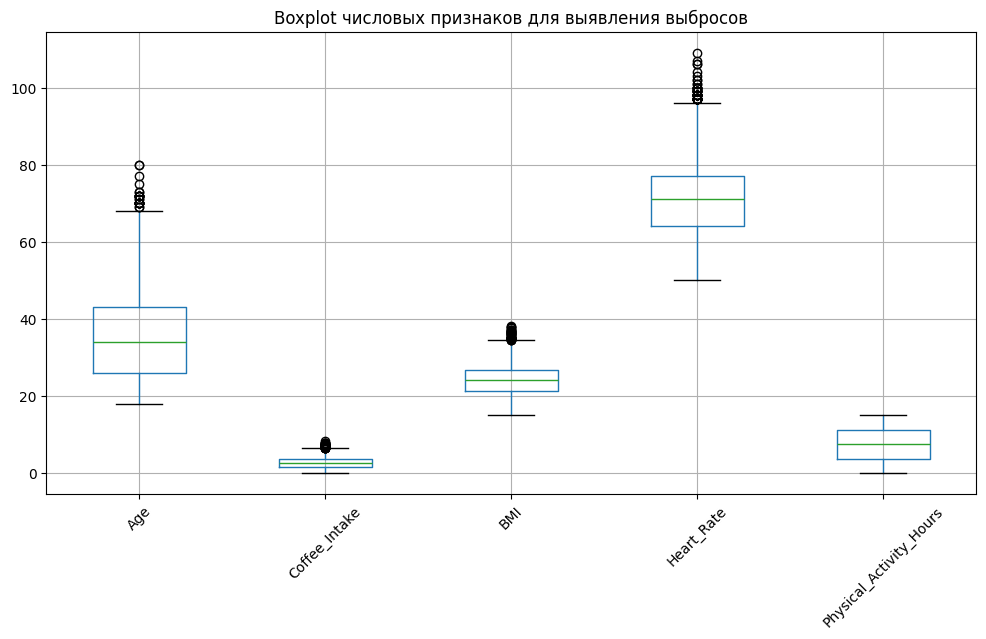

In [ ]:
plt.figure(figsize=(12,6))
df[['Age','Coffee_Intake','BMI','Heart_Rate','Physical_Activity_Hours']].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot числовых признаков для выявления выбросов")
plt.show()

##**Задача проекта: классификация. Предсказание уровня стресса (Stress_Level) на основе повседневных привычек и физиологических параметров (потребление кофе, сон, пульс, курение).**

Поскольку некоторые данные категориальные, перекодируем их в числовые

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

df_processed = df.copy()

# Заполняем пропуски в Health_Issues значением 'None'
df_processed['Health_Issues'] = df_processed['Health_Issues'].fillna('None')

sleep_categories = [['Poor', 'Fair', 'Good', 'Excellent']]
health_categories = [['Severe', 'Moderate', 'Mild', 'None']]   # Severe - худшее, None - лучшее

ord_enc_sleep = OrdinalEncoder(categories=sleep_categories)
df_processed['Sleep_Quality'] = ord_enc_sleep.fit_transform(df_processed[['Sleep_Quality']])

ord_enc_health = OrdinalEncoder(categories=health_categories)
df_processed['Health_Issues'] = ord_enc_health.fit_transform(df_processed[['Health_Issues']])

le_gender = LabelEncoder()
le_country = LabelEncoder()
le_occupation = LabelEncoder()

df_processed['Gender'] = le_gender.fit_transform(df_processed['Gender'])
df_processed['Country'] = le_country.fit_transform(df_processed['Country'])
df_processed['Occupation'] = le_occupation.fit_transform(df_processed['Occupation'])

Теперь данные преобразованы:


**Gender:**

Female = 0

Male = 1

Other = 2

**Sleep_Quality:**

Poor = 0

Fair = 1

Good = 2

Excellent = 3

**Health_Issues:**

Severe = 0

Moderate = 1

Mild = 2

None = 3

**Occupation:**

Healthcare = 0

Office = 1

Other = 2

Service = 3

Student = 4



Удалим технический признак ID и избыточный признак Caffeine_mg, так как он линейно зависим от Coffee_Intake. Также, исключаем Sleep_Hours и Sleep_Quality во избежание утечки данных (data leakage), так как целевой признак Stress_Level был сгенерирован на их основе.

In [ ]:
columns_to_drop = ['ID', 'Caffeine_mg', 'Sleep_Hours', 'Sleep_Quality']
df_processed = df_processed.drop(columns=columns_to_drop)

print("Признаки после отбора:")
print(df_processed.columns.tolist())

Признаки после отбора:
['Age', 'Gender', 'Country', 'Coffee_Intake', 'BMI', 'Heart_Rate', 'Stress_Level', 'Physical_Activity_Hours', 'Health_Issues', 'Occupation', 'Smoking', 'Alcohol_Consumption']


Выделим целевую переменную (Stress_Level) и масштабируем числовые признаки с помощью StandardScaler, чтобы привести их к единому масштабу.

In [ ]:
X = df_processed.drop(columns=['Stress_Level'])
y = df_processed['Stress_Level']
le_target = LabelEncoder()
y = le_target.fit_transform(y)

numeric_cols = ['Age', 'Coffee_Intake', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("Размер матрицы признаков:", X_scaled.shape)
display(X_scaled.head())

Размер матрицы признаков: (10000, 11)


,Age,Gender,Country,Coffee_Intake,BMI,Heart_Rate,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,0.452574,1,7,0.683207,0.233766,0.751563,1.625265,3,2,0,0
1,-0.174645,1,7,-1.040723,-1.020645,-0.368319,0.814134,3,3,0,0
2,0.631779,1,2,1.924437,-0.329439,-1.182779,0.860485,0,1,0,0
3,1.617409,1,7,0.062592,0.182565,0.038911,-0.205573,0,2,0,0
4,-0.264247,0,15,0.407378,0.028964,0.547948,0.234755,0,4,0,1


Построим тепловую карту корреляций для финального набора признаков, чтобы убедиться в отсутствии сильной взаимосвязи между ними.

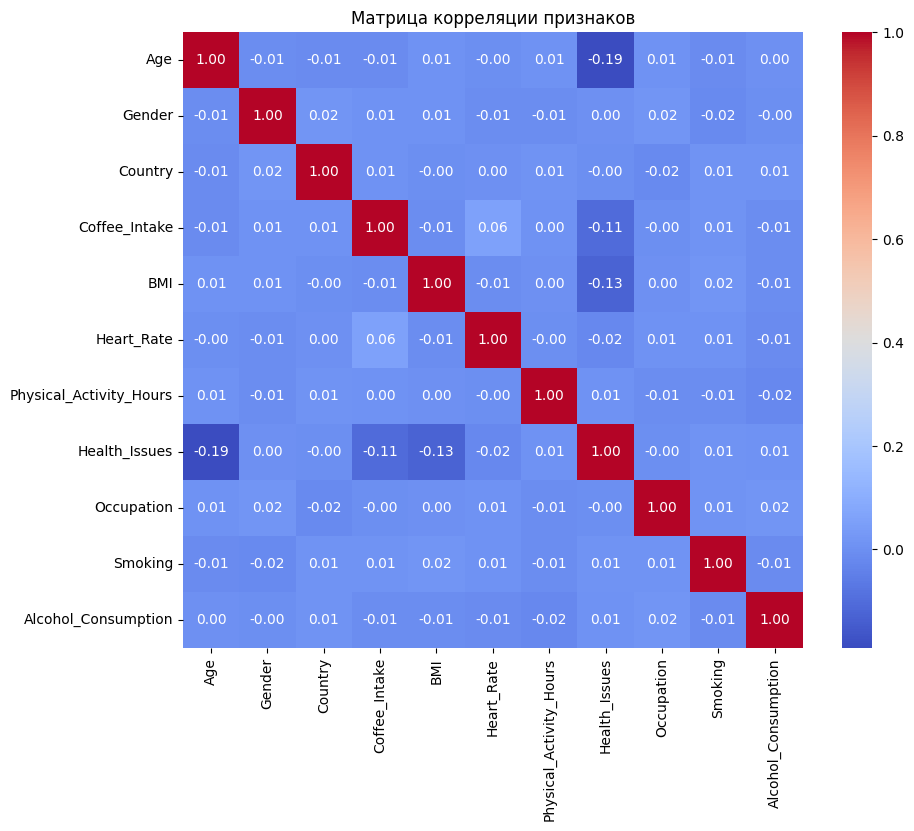

In [ ]:
import numpy as np

plt.figure(figsize=(10, 8))
sns.heatmap(X_scaled.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Матрица корреляции признаков")
plt.show()

# **3 Этап**

# **Постановка задачи и построение модели**

**Постановка задачи:**
В проекте реализуется задача мультиклассовой классификации. На основе социально-демографических, поведенческих и физиологических признаков (потребление кофе, курение, алкоголь, физическая активность, пульс, ИМТ) прогнозируется уровень стресса (`Stress_Level`), представленный классами: Low, Medium и High.

**Процесс построения моделей:**
1. **Разбиение выборки:** Данные разделены на обучающую и тестовую выборки (80/20) с применением стратификации для сохранения баланса классов в подмножествах.
2. **Исключение избыточных признаков:** Факторы `Sleep_Hours` и `Sleep_Quality` изъяты из признакового пространства для предотвращения утечки данных (data leakage), так как целевая переменная функционально зависит от параметров сна.
3. **Выбор алгоритмов:** Для сравнительного анализа были выбраны три модели:
   * Логистическая регрессия (`LogisticRegression`) — базовый линейный классификатор.
   * Метод k-ближайших соседей (`KNeighborsClassifier`) — метрический алгоритм.
   * Случайный лес (`RandomForestClassifier`) — ансамблевый метод на основе решающих деревьев для аппроксимации нелинейных зависимостей.

Разделим выборку на обучающую (Train) и тестовую (Test) в соотношении 80/20. Применим стратификацию по целевой переменной y, чтобы сохранить баланс классов уровня стресса в обеих выборках.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (8000, 11)
Размер тестовой выборки: (2000, 11)


Обучим три различные модели для решения задачи мультиклассовой классификации: логистическую регрессию, KNN и Random Forest.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

log_reg = LogisticRegression(max_iter=1000, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
rf_clf = RandomForestClassifier(random_state=42)

log_reg.fit(X_train, y_train)
knn.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

print("Все модели успешно обучены")

Все модели успешно обучены


Получим предсказания моделей на тестовой выборке для последующей оценки результатов.

In [ ]:
y_pred_log_reg = log_reg.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

# **4 Этап**

# **Оценка модели и результатов**

Оценим качество обученных моделей на тестовой выборке с помощью матрицы ошибок (Confusion Matrix) и основных метрик классификации: Accuracy, Precision, Recall и F1-score.

Logistic Regression Classification Report
              precision    recall  f1-score   support

         Low       1.00      0.01      0.01       192
      Medium       0.93      0.92      0.93      1398
        High       0.57      0.85      0.68       410

    accuracy                           0.82      2000
   macro avg       0.83      0.59      0.54      2000
weighted avg       0.86      0.82      0.79      2000

KNN Classification Report
              precision    recall  f1-score   support

         Low       0.27      0.24      0.25       192
      Medium       0.95      0.94      0.95      1398
        High       0.59      0.64      0.62       410

    accuracy                           0.81      2000
   macro avg       0.60      0.61      0.61      2000
weighted avg       0.81      0.81      0.81      2000

Random Forest Classification Report
              precision    recall  f1-score   support

         Low       0.30      0.05      0.09       192
      Medium       1.00  

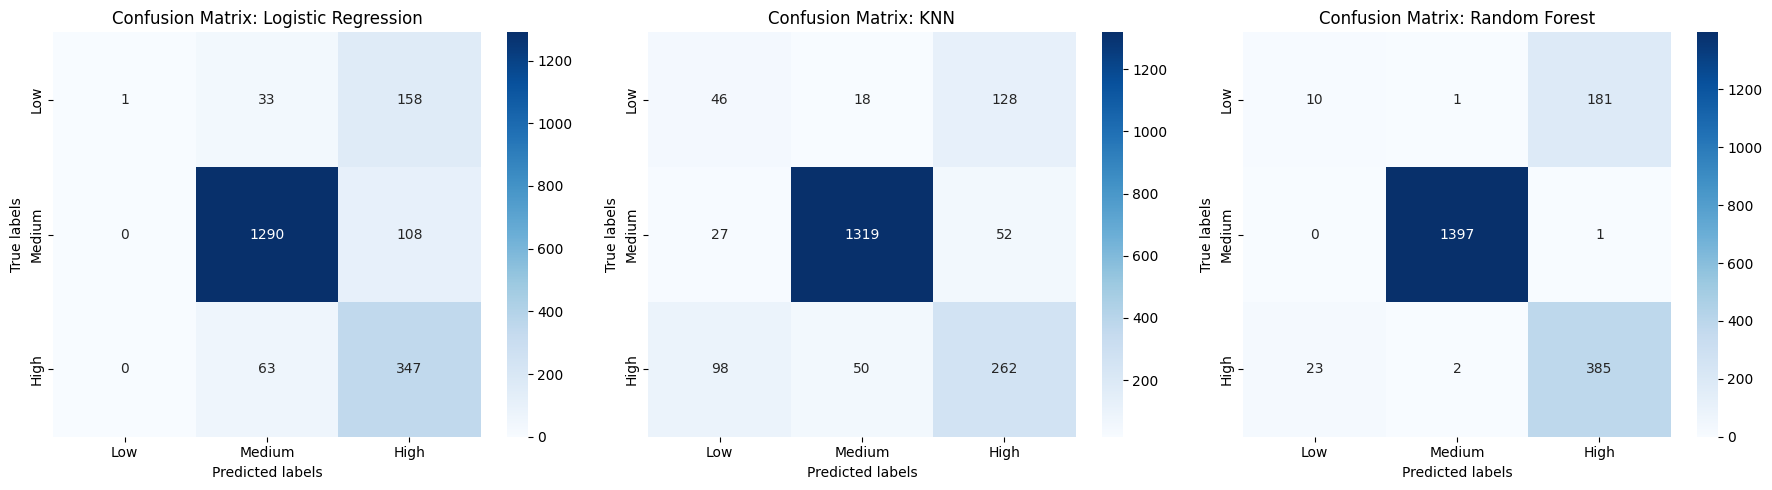

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

models = {
    'Logistic Regression': y_pred_log_reg,
    'KNN': y_pred_knn,
    'Random Forest': y_pred_rf
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = ['Low', 'Medium', 'High']

for ax, (model_name, preds) in zip(axes, models.items()):
    print(f"{model_name} Classification Report")
    print(classification_report(y_test, preds, target_names=class_labels))

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels)
    ax.set_title(f'Confusion Matrix: {model_name}')
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')

plt.tight_layout()
plt.show()

Кросс-валидация моделей

In [ ]:
from sklearn.model_selection import cross_val_score

models_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(random_state=42)
}

for name, model in models_cv.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    print(f"{name}: средняя точность = {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression: средняя точность = 0.814 (+/- 0.009)
KNN: средняя точность = 0.822 (+/- 0.005)
Random Forest: средняя точность = 0.894 (+/- 0.002)


## Анализ точности и обоснованности результатов моделирования

В ходе исследования эффективности трех алгоритмов машинного обучения (`Logistic Regression`, `KNN`, `Random Forest`) для предсказания уровня стресса были получены следующие результаты:

1. **Общая оценка качества моделей (Accuracy):**
   * Наивысшую общую точность показал алгоритм **Random Forest (Accuracy = 0.90)**.
   * Логистическая регрессия продемонстрировала результат **0.82**, а метод k-ближайших соседей (KNN) — **0.81**.

2. **Анализ влияния дисбаланса классов на основе метрик и Confusion Matrix:**
   * В тестовой выборке наблюдается выраженный дисбаланс: класс `Medium` значительно преобладает (1398 наблюдений). Из-за этого все три модели хорошо научились распознавать средний уровень стресса (Precision и Recall для `Medium` близки к 0.92–1.00).
   * **Класс Low (Низкий стресс):** Обнаружена общая проблема у всех моделей — крайне низкая полнота ($Recall$) на уровне 0.01 (Логистическая регрессия) и 0.05 (Случайный лес). Матрицы ошибок визуализируют, что объекты класса `Low` ошибочно классифицируются моделями как `High` или `Medium`. Исключением стал алгоритм **KNN**, который смог корректно уловить 46 объектов из 192 ($Recall = 0.24$), однако его общая точность ($Precision = 0.27$) остается неудовлетворительной.
   * **Класс High (Высокий стресс):** Алгоритм **Random Forest** показал наилучший баланс предсказательной способности для зоны высокого риска: $Recall = 0.94$ при $Precision = 0.68$, успешно определив 385 истинных случаев из 410.



### Итоговый вывод
Для практического применения обосновано использование модели **Random Forest**. Несмотря на затруднения с идентификацией редкого класса `Low`, ансамблевый метод обеспечил наилучшую точность в 90% и гарантировал качественное выявление участников с высоким уровнем стресса (`High`), что является приоритетной задачей в рамках мониторинга ментального здоровья.